<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Metropolis_Sampling_for_Curie_Temperature_Simulation_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [5]:
!uv pip install cupy-cuda12x matplotlib numpy scipy

Using Python 3.12.13 environment at: /usr
Checked 4 packages in 100ms


Simulating Symmetric Metropolis Thermal Evolution...
Estimated Critical Temperature from Susceptibility Peak: 89.66 K


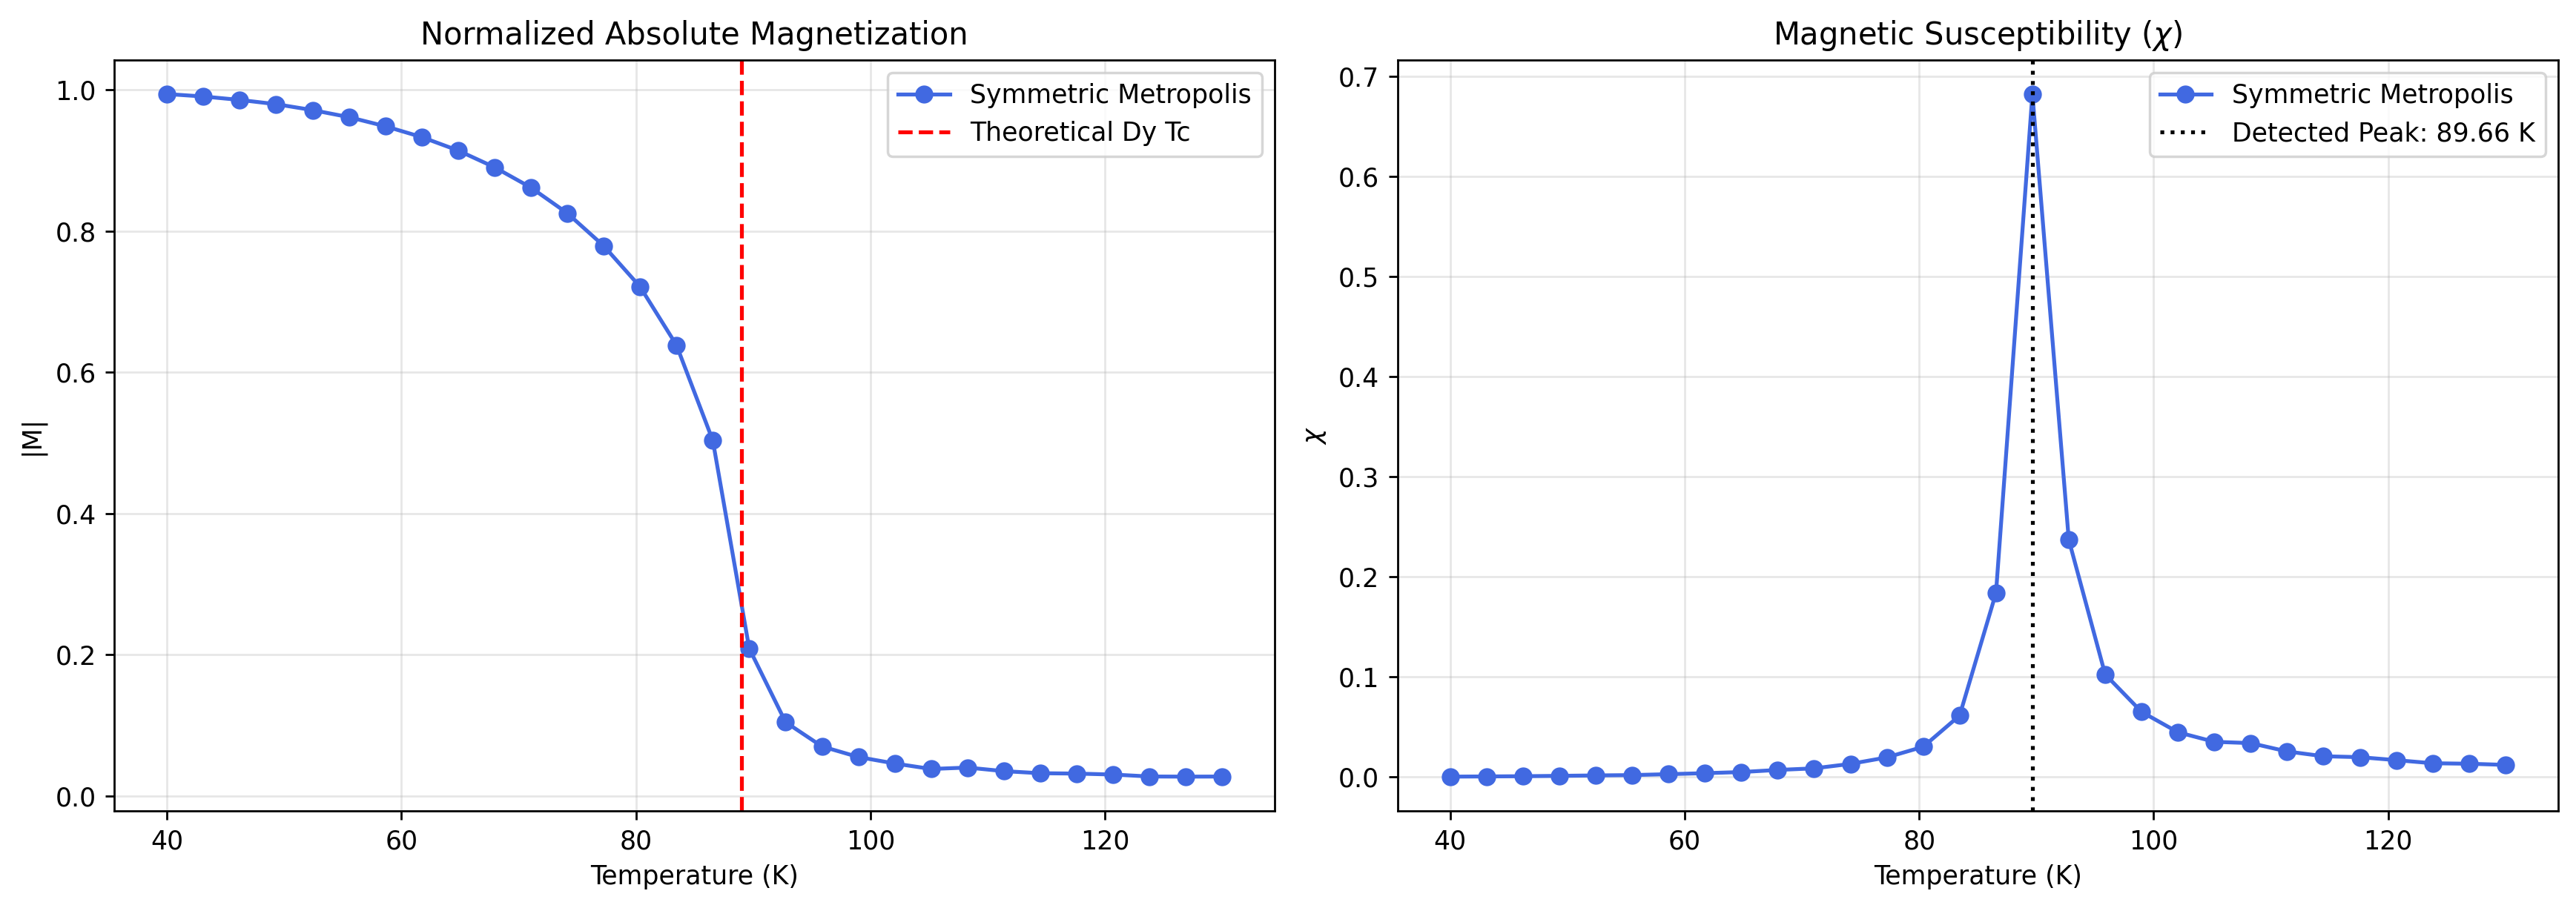

In [10]:
"""This script evaluates the Curie temperature of Dysprosium using a Three Dimensional Ising Model.

The computational framework utilizes a Symmetric Markov Chain Monte Carlo (MCMC)
Metropolis algorithm to determine the Critical Temperature (Tc) by analyzing the
peak of Magnetic Susceptibility, entirely omitting asymmetric evaluation logic
for enhanced physical accuracy.
"""

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

# ---------------------------------------------------
# CONTROL KNOBS
# ---------------------------------------------------
LATTICE_DIMENSION = 16
NUM_TEMPERATURES = 30
TEMPERATURE_START = 40.0
TEMPERATURE_END = 130.0

EQUILIBRATION_STEPS = 1000
MEASUREMENT_STEPS = 1000

# Tuned to approximate the Dysprosium Tc around 89 Kelvin for a 3D Ising approximation
EXCHANGE_COUPLING_J = 19.73
BOLTZMANN_CONSTANT = 1.0
# ---------------------------------------------------

plt.rcParams['figure.dpi'] = 250
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'


def metropolis_symmetric_sweep(lattice, beta, j_coupling):
    """Performs one parallelized sweep of the symmetric MCMC algorithm.

    Args:
        lattice (cupy.ndarray): The matrix representing the 3D spin lattice.
        beta (float): The Inverse Thermodynamic Temperature.
        j_coupling (float): The physical Exchange Coupling Constant.

    Returns:
        cupy.ndarray: The processed spin lattice configuration matrix.
    """
    x_idx, y_idx, z_idx = cp.indices(lattice.shape)

    mask_even = (x_idx + y_idx + z_idx) % 2 == 0
    mask_odd = (x_idx + y_idx + z_idx) % 2 == 1

    for mask in [mask_even, mask_odd]:
        neighbors = (
            cp.roll(lattice, 1, axis=0) + cp.roll(lattice, -1, axis=0) +
            cp.roll(lattice, 1, axis=1) + cp.roll(lattice, -1, axis=1) +
            cp.roll(lattice, 1, axis=2) + cp.roll(lattice, -1, axis=2)
        )

        delta_energy = 2.0 * j_coupling * lattice * neighbors
        probabilities = cp.exp(-beta * delta_energy)
        random_matrix = cp.random.rand(*lattice.shape)

        flip_condition = mask & ((delta_energy <= 0) | (random_matrix < probabilities))
        lattice[flip_condition] *= -1

    return lattice


def perform_simulation(temperatures, lattice_dim, j_coupling, eq_steps, meas_steps):
    """Simulates the physical system across a designated range of thermodynamic temperatures.

    Args:
        temperatures (cupy.ndarray): The array of thermal setpoints to sample.
        lattice_dim (int): The linear dimension of the cubic lattice.
        j_coupling (float): The physical Exchange Coupling Constant.
        eq_steps (int): The quantity of equilibration sweeps.
        meas_steps (int): The quantity of measurement sweeps.

    Returns:
        tuple: A pair of arrays containing the computed magnetizations and susceptibilities.
    """
    magnetizations = cp.zeros(len(temperatures))
    susceptibilities = cp.zeros(len(temperatures))
    total_spins = lattice_dim ** 3
    lattice = cp.ones((lattice_dim, lattice_dim, lattice_dim))

    for idx, t_val in enumerate(temperatures):
        beta = 1.0 / (BOLTZMANN_CONSTANT * t_val)

        for _ in range(eq_steps):
            lattice = metropolis_symmetric_sweep(lattice, beta, j_coupling)

        mag_sum = 0.0
        mag_squared_sum = 0.0

        for _ in range(meas_steps):
            lattice = metropolis_symmetric_sweep(lattice, beta, j_coupling)

            current_magnetization = cp.sum(lattice) / total_spins
            mag_sum += cp.abs(current_magnetization)
            mag_squared_sum += current_magnetization ** 2

        average_mag = mag_sum / meas_steps
        average_mag_squared = mag_squared_sum / meas_steps
        variance_mag = average_mag_squared - (average_mag ** 2)

        magnetizations[idx] = average_mag
        susceptibilities[idx] = (total_spins / (BOLTZMANN_CONSTANT * t_val)) * variance_mag

    return magnetizations, susceptibilities


def main():
    """Executes the uniform physics simulation and renders the resulting susceptibility peaks."""
    temperatures = cp.linspace(TEMPERATURE_START, TEMPERATURE_END, NUM_TEMPERATURES)

    print("Simulating Symmetric Metropolis Thermal Evolution...")
    mag_symmetric, chi_symmetric = perform_simulation(
        temperatures, LATTICE_DIMENSION, EXCHANGE_COUPLING_J,
        EQUILIBRATION_STEPS, MEASUREMENT_STEPS
    )

    t_cpu = cp.asnumpy(temperatures)
    mag_s_cpu = cp.asnumpy(mag_symmetric)
    chi_s_cpu = cp.asnumpy(chi_symmetric)

    peak_indices, _ = signal.find_peaks(chi_s_cpu)
    estimated_tc = t_cpu[peak_indices[0]] if len(peak_indices) > 0 else None

    if estimated_tc:
        print(f"Estimated Critical Temperature from Susceptibility Peak: {estimated_tc:.2f} K")
    else:
        print("No definitive magnetic susceptibility peak was detected.")

    fig, (axis_1, axis_2) = plt.subplots(1, 2, figsize=(14, 5))

    axis_1.plot(t_cpu, mag_s_cpu, marker='o', linestyle='solid', label='Symmetric Metropolis', color='royalblue')
    axis_1.axvline(x=89.0, color='red', linestyle='dashed', label='Theoretical Dy Tc')
    axis_1.set_title('Normalized Absolute Magnetization')
    axis_1.set_xlabel('Temperature (K)')
    axis_1.set_ylabel('|M|')
    axis_1.legend()
    axis_1.grid(True, alpha=0.3)

    axis_2.plot(t_cpu, chi_s_cpu, marker='o', linestyle='solid', color='royalblue', label='Symmetric Metropolis')
    if estimated_tc:
        axis_2.axvline(x=estimated_tc, color='black', linestyle='dotted', label=f'Detected Peak: {estimated_tc:.2f} K')
    else:
        axis_2.axvline(x=89.0, color='black', linestyle='dotted', label='Theoretical Tc')

    axis_2.set_title(r'Magnetic Susceptibility ($\chi$)')
    axis_2.set_xlabel('Temperature (K)')
    axis_2.set_ylabel(r'$\chi$')
    axis_2.legend()
    axis_2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    main()